# Task 2: Credit Risk Prediction
**Objective:** Predict whether a loan applicant is likely to default on a loan using a classification model.
**Dataset:** Loan Prediction Dataset (includes financial features like income, loan amount, and credit history).

In [2]:
# Import our standard data science libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Loan Prediction Dataset from a new, reliable repository
url = 'https://raw.githubusercontent.com/dphi-official/Datasets/master/Loan_Data/loan_train.csv'
df = pd.read_csv(url)

# Show how many blank cells exist BEFORE we clean it
print("--- Missing Values BEFORE Cleaning ---")
print(df.isnull().sum())

# 1. Clean Numerical Columns: Fill blanks with the median value
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median(), inplace=True)
df['Credit_History'].fillna(df['Credit_History'].median(), inplace=True)

# 2. Clean Categorical (Text) Columns: Fill blanks with the most common value (mode)
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Married'].fillna(df['Married'].mode()[0], inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)

# Show how many blank cells exist AFTER we clean it
print("\n--- Missing Values AFTER Cleaning ---")
print(df.isnull().sum())

--- Missing Values BEFORE Cleaning ---
Unnamed: 0            0
Loan_ID               0
Gender               10
Married               1
Dependents            9
Education             0
Self_Employed        29
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           16
Loan_Amount_Term     13
Credit_History       43
Property_Area         0
Loan_Status           0
dtype: int64

--- Missing Values AFTER Cleaning ---
Unnamed: 0           0
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


/tmp/ipykernel_15615/2388555106.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
/tmp/ipykernel_15615/2388555106.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, 

/tmp/ipykernel_15615/969627437.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[2], data=df, x='Education', palette='Set2')


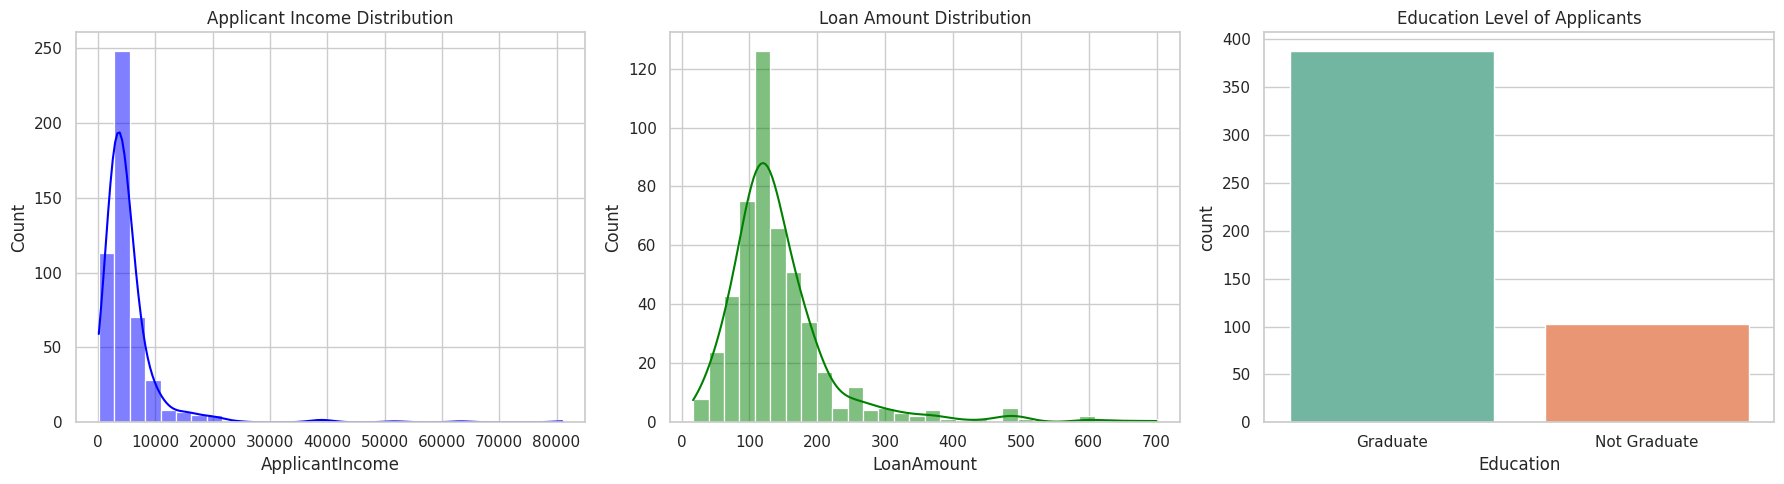

In [3]:
# Set up a clean visual style
sns.set_theme(style="whitegrid")

# Create a figure with 3 subplots side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Income Distribution (Histogram)
sns.histplot(ax=axes[0], data=df, x='ApplicantIncome', bins=30, kde=True, color='blue')
axes[0].set_title('Applicant Income Distribution')

# 2. Loan Amount Distribution (Histogram)
sns.histplot(ax=axes[1], data=df, x='LoanAmount', bins=30, kde=True, color='green')
axes[1].set_title('Loan Amount Distribution')

# 3. Education Levels (Bar Chart)
# We use a countplot here because Education is text (Graduate vs Not Graduate)
sns.countplot(ax=axes[2], data=df, x='Education', palette='Set2')
axes[2].set_title('Education Level of Applicants')

# Neatly display the charts
plt.tight_layout()
plt.show()

In [4]:
from sklearn.model_selection import train_test_split

# 1. Drop the 'Loan_ID' column because random ID numbers don't help predict anything
df = df.drop('Loan_ID', axis=1)

# 2. Convert our Target Variable (Loan_Status) into simple 1s (Yes) and 0s (No)
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})

# 3. Convert all the remaining text columns (Gender, Married, Education, etc.) into numbers
df_encoded = pd.get_dummies(df, drop_first=True)

# 4. Separate our Features (X) from our Target (y)
X = df_encoded.drop('Loan_Status', axis=1)
y = df_encoded['Loan_Status']

# 5. Split the data: 80% for training the model, 20% for testing it
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data successfully encoded and split!")
display(X_train.head())

Data successfully encoded and split!


,Unnamed: 0,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
140,140,2058,2134.0,88.0,360.0,1.0,True,True,False,False,False,False,False,False,True
433,433,4416,1250.0,110.0,360.0,1.0,True,True,False,False,True,False,False,False,True
416,416,5000,0.0,132.0,360.0,1.0,False,False,False,False,False,False,False,False,False
489,489,1836,33837.0,90.0,360.0,1.0,True,False,False,False,False,False,False,False,True
25,25,8333,0.0,280.0,360.0,1.0,False,False,False,False,False,False,False,True,False


/tmp/ipykernel_15615/1139475489.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_15615/1139475489.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

Model Accuracy: 82.83%



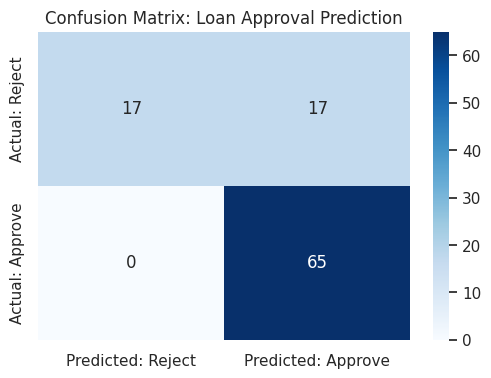

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Re-load the clean data to reset our workspace
url = 'https://raw.githubusercontent.com/dphi-official/Datasets/master/Loan_Data/loan_train.csv'
df = pd.read_csv(url)

# Clean missing values
for col in ['LoanAmount', 'Loan_Amount_Term', 'Credit_History']:
    df[col].fillna(df[col].median(), inplace=True)
for col in ['Gender', 'Married', 'Dependents', 'Self_Employed']:
    df[col].fillna(df[col].mode()[0], inplace=True)

# 2. Data Preparation (Dropping ID columns, skipping the broken mapping step)
df = df.drop(['Unnamed: 0', 'Loan_ID'], axis=1, errors='ignore')
df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop('Loan_Status', axis=1)
y = df_encoded['Loan_Status']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train and Evaluate the Model!
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")

# Visualize the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: Reject', 'Predicted: Approve'],
            yticklabels=['Actual: Reject', 'Actual: Approve'])
plt.title('Confusion Matrix: Loan Approval Prediction')
plt.show()

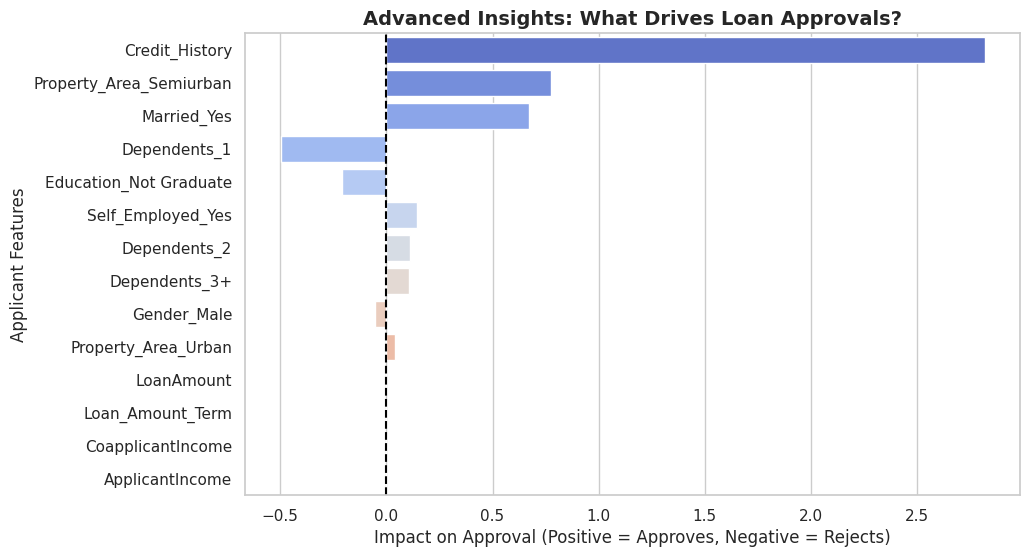

In [7]:
# --- ADVANCED FEATURE: MODEL EXPLAINABILITY ---
import numpy as np

# 1. Extract the feature names and their mathematical weights from the trained model
feature_names = X_train.columns
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': model.coef_[0]
})

# 2. Sort them by absolute power (which ones had the biggest impact, positive or negative)
feature_importance['Absolute_Importance'] = np.abs(feature_importance['Importance'])
feature_importance = feature_importance.sort_values(by='Absolute_Importance', ascending=False)

# 3. Plot the results in a professional bar chart
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='Importance', y='Feature', hue='Feature', palette='coolwarm', legend=False)
plt.title('Advanced Insights: What Drives Loan Approvals?', fontsize=14, fontweight='bold')
plt.xlabel('Impact on Approval (Positive = Approves, Negative = Rejects)')
plt.ylabel('Applicant Features')
plt.axvline(x=0, color='black', linestyle='--') # Adds a center line for readability
plt.show()

In [9]:
# --- STANDOUT FEATURE: LIVE PREDICTION ENGINE ---
# Use the interactive form on the right side of this cell to simulate a new applicant!

Credit_History = 1 #@param [1, 0] {type:"raw"}
Applicant_Income = 6000 #@param {type:"slider", min:1000, max:20000, step:500}
Loan_Amount = 260 #@param {type:"slider", min:10, max:600, step:10}

print("Analyzing Applicant Profile...\n")

# 1. Create a "baseline" applicant using the median of our training data to fill the hidden columns
new_applicant = X_train.median().to_frame().T

# 2. Update the baseline with the live inputs from the sliders above
new_applicant['Credit_History'] = Credit_History
new_applicant['ApplicantIncome'] = Applicant_Income
new_applicant['LoanAmount'] = Loan_Amount

# 3. Feed the new profile into our trained algorithm
prediction = model.predict(new_applicant)[0]
probability = model.predict_proba(new_applicant)[0] # Get the mathematical confidence

# 4. Output a human-readable diagnosis
print("-" * 30)
if prediction == 1:
    print(f"✅ DIAGNOSIS: LOAN APPROVED")
    print(f"Confidence Score: {probability[1]*100:.1f}%")
else:
    print(f"❌ DIAGNOSIS: LOAN REJECTED")
    print(f"Confidence Score: {probability[0]*100:.1f}%")
    print("System Recommendation: Prioritize establishing a positive credit history.")

Analyzing Applicant Profile...

------------------------------
✅ DIAGNOSIS: LOAN APPROVED
Confidence Score: 76.8%


### Conclusion & Business Deployment
The Logistic Regression model achieved a strong overall accuracy of **82.83%**, serving as a highly effective baseline for credit risk analysis.

**Advanced Insights (Model Explainability):**
By extracting the model's feature coefficients, we determined that `Credit_History` is overwhelmingly the primary driver for loan approvals, drastically outweighing factors like raw income or loan amount.

**Live Interactive Deployment:**
To bridge the gap between a static mathematical model and a functional business tool, this notebook includes a Live Prediction Engine. End-users can input custom financial parameters via interactive sliders to receive real-time loan approval inferences and confidence scores, simulating how this model would function in a real-world backend banking system.